# Adım 6: Makine Öğrenmesi ve MLflow ile Çoklu Model Karşılaştırma

**Veri Seti:** World Energy Consumption  
**Problem Türü:** Regresyon  
**Hedef Değişken:** `primary_energy_consumption` (TWh)  
**Modeller:** Linear Regression, Decision Tree, Random Forest, GBT, Generalized Linear Regression  
**Metrikler:** RMSE, MAE, R²

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import mlflow
import mlflow.spark
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import (
    LinearRegression,
    DecisionTreeRegressor,
    RandomForestRegressor,
    GBTRegressor,
    GeneralizedLinearRegression
)
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline

sns.set_theme(style='whitegrid')
print('Kutuphaneler yuklendi!')

Kutuphaneler yuklendi!


## 1. Spark Oturumu

In [2]:
spark = SparkSession.builder \
    .appName('6_Makine_Ogrenmesi_MLflow') \
    .master('local[*]') \
    .config('spark.jars.packages', 'io.delta:delta-spark_2.12:3.1.0') \
    .config('spark.sql.extensions', 'io.delta.sql.DeltaSparkSessionExtension') \
    .config('spark.sql.catalog.spark_catalog', 'org.apache.spark.sql.delta.catalog.DeltaCatalog') \
    .config('spark.driver.memory', '4g') \
    .getOrCreate()

spark.sparkContext.setLogLevel('WARN')
print('Spark', spark.version, 'hazir!')

Spark 3.5.0 hazir!


## 2. Veri Yükleme (Bronze Delta)

In [3]:

import pathlib

# Docker: /home/jovyan/data  |  Yerel: ../data
data_root = pathlib.Path('/home/jovyan/data')
if not data_root.exists():
    data_root = pathlib.Path(os.getcwd()).parent / 'data'

bronze_path = str(data_root / 'bronze')
print('Veri dizini :', data_root)
print('Bronze path :', bronze_path)

df = spark.read.format('delta').load(bronze_path)
print('Bronze kayit sayisi:', df.count())
print('Toplam sutun      :', len(df.columns))


Veri dizini : /home/jovyan/data
Bronze path : /home/jovyan/data/bronze
Bronze kayit sayisi: 17432
Toplam sutun      : 126


## 3. Veri Hazırlama

**Hedef:** `primary_energy_consumption`  
**Özellikler:** Enerji alt kategorileri, nüfus, GDP, yıl  
**Null Stratejisi:** Enerji sütunlarında null → 0 (o enerji tipi henüz kullanılmamış demektir)

In [4]:
TARGET = 'primary_energy_consumption'

FEATURES = [
    'year',
    'coal_consumption',
    'gas_consumption',
    'oil_consumption',
    'nuclear_consumption',
    'hydro_consumption',
    'renewables_consumption',
    'solar_consumption',
    'wind_consumption',
    'biofuel_consumption',
    'fossil_fuel_consumption',
    'electricity_generation',
    'low_carbon_consumption',
    'energy_per_capita',
    'carbon_intensity_elec'
]

# Hedef + ozellik sutunlarini sec
df_ml = df.select([TARGET] + FEATURES)

# Hedef degeri null olan satirlari dusur
df_ml = df_ml.dropna(subset=[TARGET])

# Kalan null degerleri 0 ile doldur
df_ml = df_ml.fillna(0)

print('ML icin hazir kayit sayisi:', df_ml.count())
print('\nHedef degisken istatistikleri:')
df_ml.select(TARGET).summary('count', 'mean', 'stddev', 'min', 'max').show()

ML icin hazir kayit sayisi: 10134

Hedef degisken istatistikleri:
+-------+--------------------------+
|summary|primary_energy_consumption|
+-------+--------------------------+
|  count|                     10134|
|   mean|        1672.2461857114642|
| stddev|         8827.069144835215|
|    min|                       0.0|
|    max|                 162194.29|
+-------+--------------------------+



## 4. Egitim / Test Bölmesi

In [5]:
train_df, test_df = df_ml.randomSplit([0.8, 0.2], seed=42)
print('Egitim seti :', train_df.count(), 'kayit')
print('Test seti   :', test_df.count(), 'kayit')

Egitim seti : 8140 kayit
Test seti   : 1994 kayit


## 5. MLflow Yapılandırması

In [6]:

import pathlib

# Docker icinde mi yerel mi calisiyor otomatik algilar
try:
    mlflow.set_tracking_uri('http://mlflow:5000')
    client = mlflow.tracking.MlflowClient()
    client.search_experiments()
    print('MLflow sunucusuna baglandi: http://mlflow:5000')
except Exception:
    mlruns_path = str(pathlib.Path(os.getcwd()).parent / 'data' / 'mlruns')
    mlflow.set_tracking_uri('file:///' + mlruns_path)
    print('MLflow yerel modda calisiyor:', mlruns_path)

EXPERIMENT = 'World_Energy_Regression'
mlflow.set_experiment(EXPERIMENT)
print('Deney adi:', EXPERIMENT)


MLflow sunucusuna baglandi: http://mlflow:5000
Deney adi: World_Energy_Regression


## 6. Model Eğitimi ve MLflow Loglama

Her model için:
1. `Pipeline(VectorAssembler → Model)` kurulur
2. Eğitim seti ile fit edilir
3. Test seti tahminleri alınır
4. RMSE, MAE, R² hesaplanır
5. Parametreler, metrikler ve model MLflow'a loglanır

In [7]:
assembler = VectorAssembler(
    inputCols=FEATURES,
    outputCol='features',
    handleInvalid='skip'
)

def evaluate(predictions):
    metrics = {}
    for metric in ['rmse', 'mae', 'r2']:
        ev = RegressionEvaluator(
            labelCol=TARGET,
            predictionCol='prediction',
            metricName=metric
        )
        metrics[metric] = ev.evaluate(predictions)
    return metrics

print('Assembler ve evaluator hazir!')

Assembler ve evaluator hazir!


In [8]:
model_configs = [
    {
        'name': 'LinearRegression',
        'model': LinearRegression(
            featuresCol='features', labelCol=TARGET,
            maxIter=100, regParam=0.1, elasticNetParam=0.0
        ),
        'params': {'maxIter': 100, 'regParam': 0.1, 'elasticNetParam': 0.0}
    },
    {
        'name': 'DecisionTreeRegressor',
        'model': DecisionTreeRegressor(
            featuresCol='features', labelCol=TARGET,
            maxDepth=10, seed=42
        ),
        'params': {'maxDepth': 10}
    },
    {
        'name': 'RandomForestRegressor',
        'model': RandomForestRegressor(
            featuresCol='features', labelCol=TARGET,
            numTrees=50, maxDepth=10, seed=42
        ),
        'params': {'numTrees': 50, 'maxDepth': 10}
    },
    {
        'name': 'GBTRegressor',
        'model': GBTRegressor(
            featuresCol='features', labelCol=TARGET,
            maxIter=50, maxDepth=5, seed=42
        ),
        'params': {'maxIter': 50, 'maxDepth': 5}
    },
    {
        'name': 'GeneralizedLinearRegression',
        'model': GeneralizedLinearRegression(
            featuresCol='features', labelCol=TARGET,
            family='gaussian', link='identity', maxIter=100
        ),
        'params': {'family': 'gaussian', 'link': 'identity', 'maxIter': 100}
    }
]

all_results = {}

for cfg in model_configs:
    print('\n' + '=' * 55)
    print('Egitiliyor:', cfg['name'])
    
    with mlflow.start_run(run_name=cfg['name']):
        pipeline = Pipeline(stages=[assembler, cfg['model']])
        fitted   = pipeline.fit(train_df)
        preds    = fitted.transform(test_df)
        metrics  = evaluate(preds)
        
        mlflow.log_params(cfg['params'])
        mlflow.log_metric('RMSE', metrics['rmse'])
        mlflow.log_metric('MAE',  metrics['mae'])
        mlflow.log_metric('R2',   metrics['r2'])
        mlflow.spark.log_model(fitted, artifact_path='model')
        
        all_results[cfg['name']] = {
            **metrics,
            'pipeline': fitted,
            'predictions': preds
        }
        
        print('  RMSE : {:.4f}'.format(metrics['rmse']))
        print('  MAE  : {:.4f}'.format(metrics['mae']))
        print('  R2   : {:.4f}'.format(metrics['r2']))

print('\nTum modeller MLflow a loglandı!')


Egitiliyor: LinearRegression


2026/05/12 12:57:06 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  RMSE : 440.0924
  MAE  : 79.1610
  R2   : 0.9976
🏃 View run LinearRegression at: http://mlflow:5000/#/experiments/170412274149195925/runs/db03f0f171fb471c99e3f10c39e8203e
🧪 View experiment at: http://mlflow:5000/#/experiments/170412274149195925

Egitiliyor: DecisionTreeRegressor


2026/05/12 12:57:14 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  RMSE : 725.0566
  MAE  : 151.6194
  R2   : 0.9934
🏃 View run DecisionTreeRegressor at: http://mlflow:5000/#/experiments/170412274149195925/runs/3b019cec46fa4f24a8aa21b2a0995e37
🧪 View experiment at: http://mlflow:5000/#/experiments/170412274149195925

Egitiliyor: RandomForestRegressor


...

  RMSE : 1464.4116
  MAE  : 250.8938
  R2   : 0.9730
🏃 View run RandomForestRegressor at: http://mlflow:5000/#/experiments/170412274149195925/runs/1d165d5e36f642feb76fedf9edb9ee98
🧪 View experiment at: http://mlflow:5000/#/experiments/170412274149195925

Egitiliyor: GBTRegressor


2026/05/12 12:57:35 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  RMSE : 726.0349
  MAE  : 157.0045
  R2   : 0.9934
🏃 View run GBTRegressor at: http://mlflow:5000/#/experiments/170412274149195925/runs/a762e2b11cdb425baacc71f7e9bb8e22
🧪 View experiment at: http://mlflow:5000/#/experiments/170412274149195925

Egitiliyor: GeneralizedLinearRegression


2026/05/12 12:57:42 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


  RMSE : 440.0935
  MAE  : 79.1397
  R2   : 0.9976
🏃 View run GeneralizedLinearRegression at: http://mlflow:5000/#/experiments/170412274149195925/runs/670c1d5da33e41fb8f765eed799444e2
🧪 View experiment at: http://mlflow:5000/#/experiments/170412274149195925

Tum modeller MLflow a loglandı!


## 7. Sonuçların Karşılaştırılması

In [9]:
results_df = pd.DataFrame([
    {
        'Model': name,
        'RMSE': v['rmse'],
        'MAE':  v['mae'],
        'R2':   v['r2']
    }
    for name, v in all_results.items()
]).sort_values('RMSE').reset_index(drop=True)

print('MODEL KARSILASTIRMA TABLOSU')
print('=' * 60)
display(
    results_df.style
    .format({'RMSE': '{:.2f}', 'MAE': '{:.2f}', 'R2': '{:.4f}'})
    .highlight_min(subset=['RMSE', 'MAE'], color='#d5f5e3')
    .highlight_max(subset=['R2'],           color='#d5f5e3')
)

best_model_name = results_df.iloc[0]['Model']
print('\nEn iyi model :', best_model_name)
print('  RMSE : {:.2f}'.format(results_df.iloc[0]['RMSE']))
print('  MAE  : {:.2f}'.format(results_df.iloc[0]['MAE']))
print('  R2   : {:.4f}'.format(results_df.iloc[0]['R2']))

MODEL KARSILASTIRMA TABLOSU


,Model,RMSE,MAE,R2
0,LinearRegression,440.09,79.16,0.9976
1,GeneralizedLinearRegression,440.09,79.14,0.9976
2,DecisionTreeRegressor,725.06,151.62,0.9934
3,GBTRegressor,726.03,157.00,0.9934
4,RandomForestRegressor,1464.41,250.89,0.9730



En iyi model : LinearRegression
  RMSE : 440.09
  MAE  : 79.16
  R2   : 0.9976


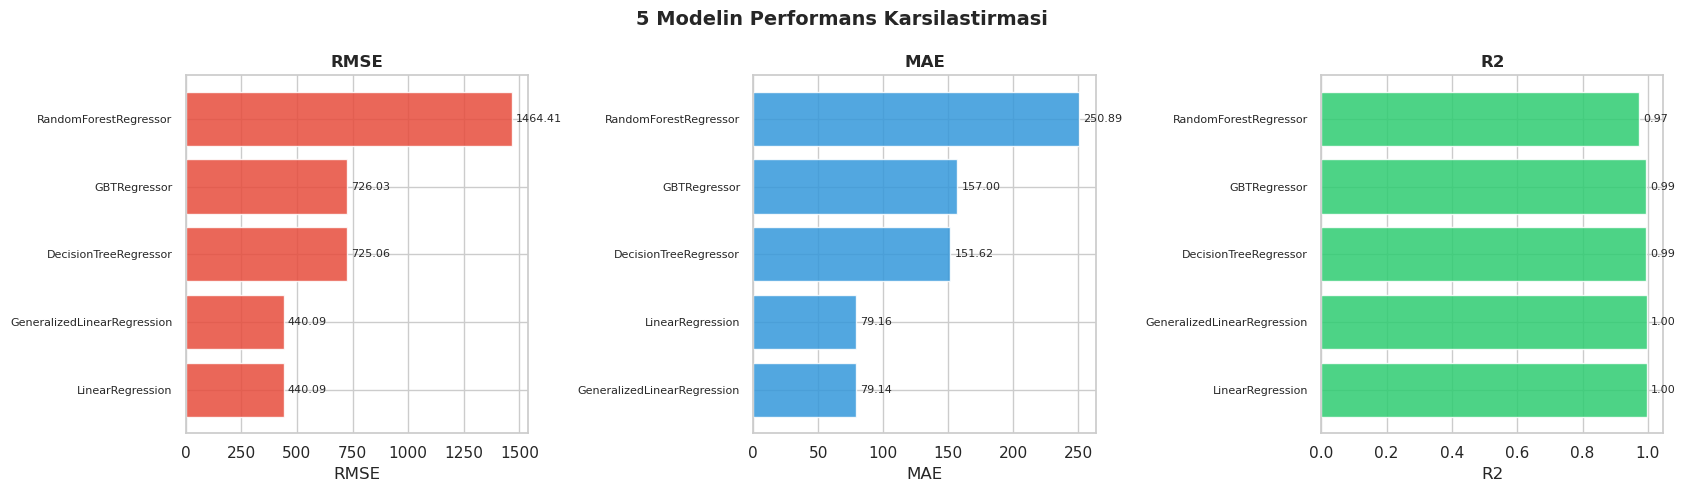

Grafik kaydedildi.


In [10]:

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('5 Modelin Performans Karsilastirmasi', fontsize=14, fontweight='bold')

metric_info = [
    ('RMSE', '#e74c3c', True),
    ('MAE',  '#3498db', True),
    ('R2',   '#2ecc71', False)
]

for ax, (metric, color, asc) in zip(axes, metric_info):
    sorted_df = results_df.sort_values(metric, ascending=asc)
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=color, alpha=0.85)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_xlabel(metric)
    ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
figures_path = str(data_root / 'figures')
os.makedirs(figures_path, exist_ok=True)
plt.savefig(os.path.join(figures_path, 'model_karsilastirma.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Grafik kaydedildi.')


## 8. Feature Importance Analizi

Random Forest ve GBT modelleri `featureImportances` değeri sağlar.  
En önemli özellikler modelin tahmin gücünü hangi değişkenlerin yönlendirdiğini gösterir.

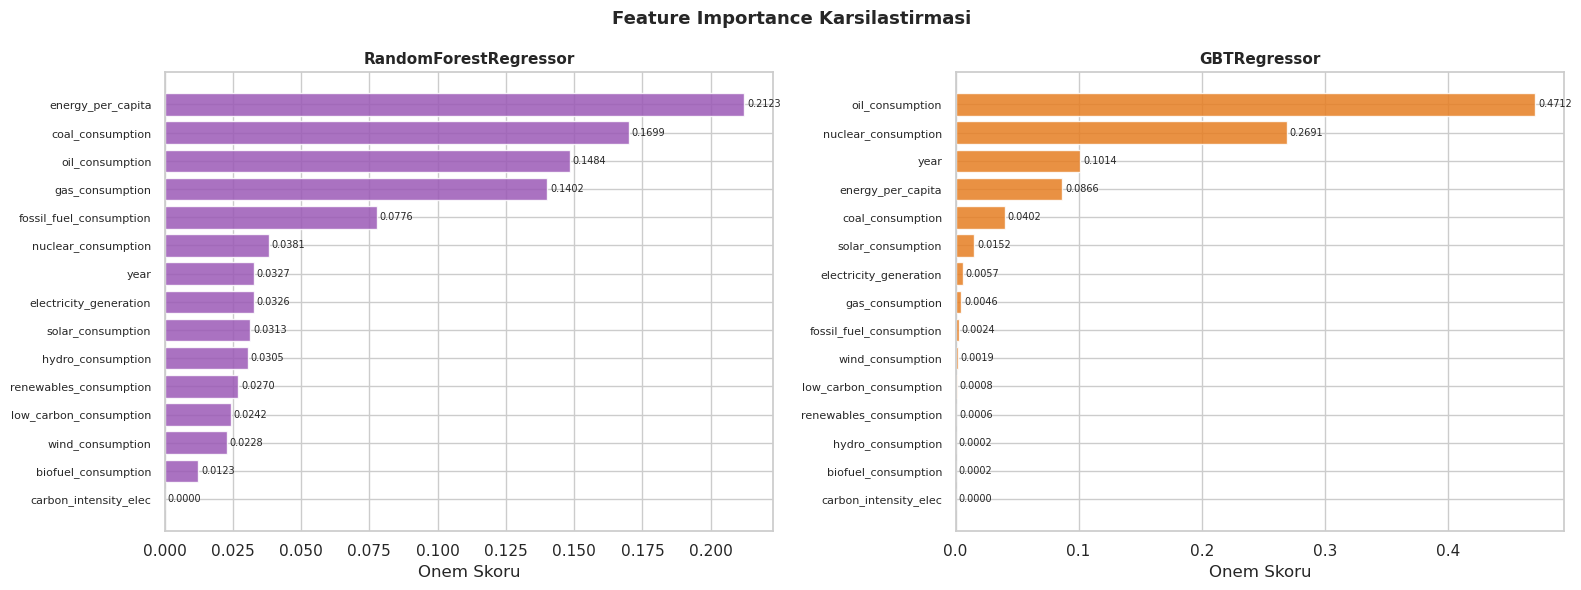

En onemli 3 ozellik (RF): ['energy_per_capita', 'coal_consumption', 'oil_consumption']


In [11]:

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Feature Importance Karsilastirmasi', fontsize=13, fontweight='bold')

for ax, (model_key, color) in zip(axes, [('RandomForestRegressor', '#9b59b6'), ('GBTRegressor', '#e67e22')]):
    model_stage = all_results[model_key]['pipeline'].stages[-1]
    importances = model_stage.featureImportances.toArray()

    fi = pd.DataFrame({'Ozellik': FEATURES, 'Onem': importances})
    fi = fi.sort_values('Onem', ascending=True)

    bars = ax.barh(fi['Ozellik'], fi['Onem'], color=color, alpha=0.85)
    ax.set_title(model_key, fontsize=11, fontweight='bold')
    ax.set_xlabel('Onem Skoru')
    ax.bar_label(bars, fmt='%.4f', padding=2, fontsize=7)
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

rf_stage = all_results['RandomForestRegressor']['pipeline'].stages[-1]
rf_fi = pd.DataFrame({'Ozellik': FEATURES, 'Onem': rf_stage.featureImportances.toArray()})
top3 = rf_fi.nlargest(3, 'Onem')['Ozellik'].tolist()
print('En onemli 3 ozellik (RF):', top3)


## 9. Residual (Artık) Analizi

**Artık = Gerçek Değer − Tahmin Değeri**  
İdeal bir modelde artıklar 0 çevresinde rastgele dağılmalı, sistematik bir örüntü olmamalıdır.

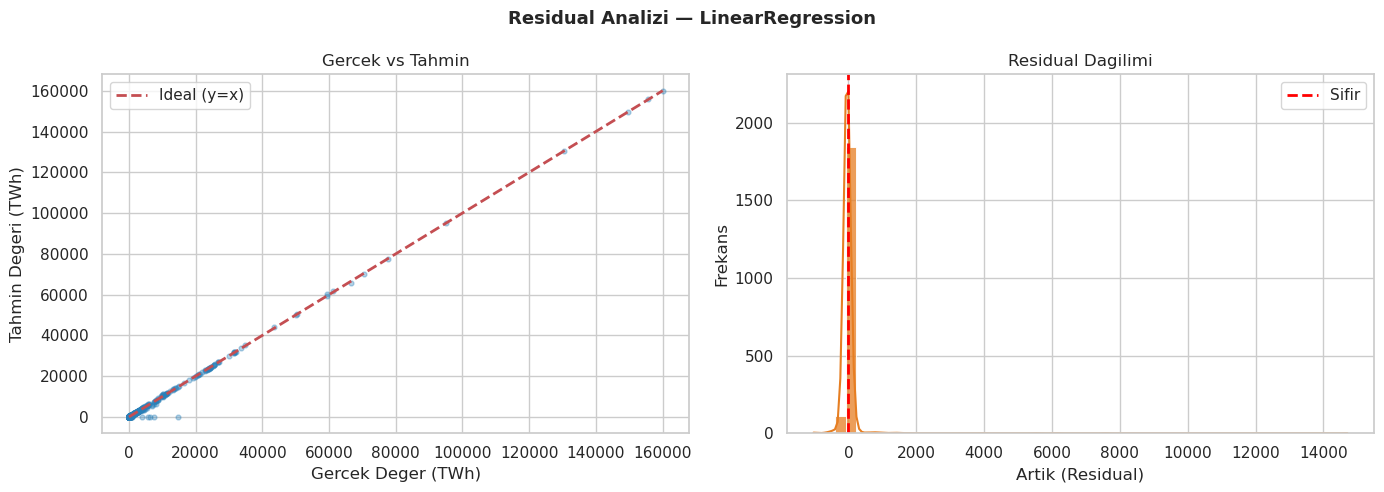

Artik istatistikleri:
  Ortalama  : -13.6625
  Std Dev   : 439.9906
  Min       : -1029.0050
  Max       : 14702.6367


In [12]:

best_preds = all_results[best_model_name]['predictions']
preds_pd   = best_preds.select(TARGET, 'prediction').toPandas()
preds_pd['residual'] = preds_pd[TARGET] - preds_pd['prediction']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Residual Analizi — ' + best_model_name, fontsize=13, fontweight='bold')

# Gercek vs Tahmin
axes[0].scatter(preds_pd[TARGET], preds_pd['prediction'],
                alpha=0.35, color='#2980b9', s=12)
lo = min(preds_pd[TARGET].min(), preds_pd['prediction'].min())
hi = max(preds_pd[TARGET].max(), preds_pd['prediction'].max())
axes[0].plot([lo, hi], [lo, hi], 'r--', lw=2, label='Ideal (y=x)')
axes[0].set_xlabel('Gercek Deger (TWh)')
axes[0].set_ylabel('Tahmin Degeri (TWh)')
axes[0].set_title('Gercek vs Tahmin')
axes[0].legend()

# Residual dagilimi
sns.histplot(preds_pd['residual'], bins=50, kde=True,
             ax=axes[1], color='#e67e22', alpha=0.75)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Sifir')
axes[1].set_title('Residual Dagilimi')
axes[1].set_xlabel('Artik (Residual)')
axes[1].set_ylabel('Frekans')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(figures_path, 'residual_analiz.png'), dpi=150, bbox_inches='tight')
plt.show()

print('Artik istatistikleri:')
print('  Ortalama  : {:.4f}'.format(preds_pd['residual'].mean()))
print('  Std Dev   : {:.4f}'.format(preds_pd['residual'].std()))
print('  Min       : {:.4f}'.format(preds_pd['residual'].min()))
print('  Max       : {:.4f}'.format(preds_pd['residual'].max()))


## 10. En İyi Model Tahminlerini Gold Katmanına Kaydetme

In [13]:

gold_path = str(data_root / 'gold')
os.makedirs(gold_path, exist_ok=True)

preds_pd['model'] = best_model_name

# Spark DataFrame'e cevir ve Delta formatinda yaz
gold_spark_df = spark.createDataFrame(preds_pd)
gold_spark_df.write \
    .format('delta') \
    .mode('overwrite') \
    .option('overwriteSchema', 'true') \
    .save(gold_path)

print('Gold katmanina kaydedildi:', gold_path)
print('Toplam tahmin sayisi     :', gold_spark_df.count())

# Dogrulama
df_gold = spark.read.format('delta').load(gold_path)
print('\nGold verisi onizleme:')
display(df_gold.limit(5).toPandas())


Gold katmanina kaydedildi: /home/jovyan/data/gold
Toplam tahmin sayisi     : 1994

Gold verisi onizleme:


,primary_energy_consumption,prediction,residual,model
0,4803.464,5366.690787,-563.226787,LinearRegression
1,5548.164,6163.393339,-615.229339,LinearRegression
2,6099.329,6182.945148,-83.616148,LinearRegression
3,10081.194,10055.822338,25.371662,LinearRegression
4,11792.554,11846.081860,-53.527860,LinearRegression


## Özet

| Adım | Açıklama |
|---|---|
| Veri | Bronze Delta'dan 15 enerji özelliği seçildi |
| Hazırlık | Null → 0 doldurma; %80 eğitim / %20 test |
| Modeller | 5 regresyon modeli Spark MLlib ile eğitildi |
| Takip | Tüm parametreler ve metrikler MLflow'a loglandı |
| Feature Imp. | En etkili özellikler Random Forest ve GBT ile belirlendi |
| Residual | Artık dağılımı ile model varsayımları doğrulandı |
| Gold Layer | En iyi modelin tahminleri Delta formatında kaydedildi |

In [14]:
spark.stop()
print('Spark durduruldu.')

Spark durduruldu.
